IA & Data science -- 2025-2026
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut, Maxellende Julienne.*


<div align="center">

### L'équipe de travail :

Medsir (Mehdi)<br>
Kyzox (Antoine)


Le code de la librairie iads ne sera pas partagé pour éviter d'avoir des problèmes si des étudiants copient notre travail... Désolé ! <br>
Néanmoins voici ce que nous avons réussi a implémenter et comment nous l'avons utilisé sur la base de données Fashion Mnist

In [4]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
%matplotlib inline  

import math
import time
import sys

# pour les dendrogrammes) :
import scipy
import graphviz as gv
# --------------------------------
# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%autosave 60
%load_ext autoreload
%autoreload 2

# --------------------------------
import seaborn as sns

Autosaving every 60 seconds


In [5]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as cl

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev

# importation de Clustering 
from iads import Clustering as clust


## Données pour le projet : Fashion MNIST

Les données sont fournies dans l'archive `data.tgz`. 
Cette archive contient 2 fichiers CSV:
- le fichier `fashion-mnist_train.csv`: ce fichier doit servir à l'entraînement de vos modèles, et leur évaluation en validation croisée,
- le fichier `fashion-mnist_test.csv`: ce fichier ne doit être utilisé que pour évaluer un modèle et il ne doit pas servir pour faire mettre au point le modèle.


Une documentation sur ces données peut être consultée sur la <a href="https://fr.wikipedia.org/wiki/Fashion_MNIST" target="NEW">page wikipedia Fashion MNIST</a>.


#### Chargement des données

In [6]:
data_train = pd.read_csv("./data/fashion-mnist_train.csv")
label = data_train["label"]
data_train = ut.normalisation(data_train)
data_train["label"] = label

In [7]:
data_test = pd.read_csv("./data/fashion-mnist_test.csv")
label = data_test["label"]
data_test = ut.normalisation(data_test)
data_test["label"] = label


In [78]:
data_train.shape

(60000, 785)

In [9]:
data_test.shape

(10000, 785)

## Tâches à réaliser

### Apprentissage supervisé

*Tâches*: évaluation d'algorithmes et de représentations des données.
- classification binaire
- classification multi-classe

*Etudes suggérées*:
- différents classifiers:
    - perceptron et variantes
    - k-plus proches voisins 
    - arbres de décision
    - ensembles de classifieurs
- analyse des résultats: comparaison des approches et de leurs hyper-paramètres
    - accuracy, temps d'exécutions
    - score fold par fold
    - matrice de confusion
    - ...


### Apprentissage non-supervisé

*Tâche*: présence éventuelle de groupes de données: groupes intra-classes, et/ou groupes interclasses.

*Etudes possibles*:
- étudier l'application d'un clustering hiérarchique et son résultat;
- étudier les résultats de l'application de l'algorithme des k-moyennes, pour différentes valeurs de k: roposer des évaluations des clusters trouvés afin de mettre en évidence les plus intéressants:
    - en utilisant les indices d'évaluation présentés en cours;
    - en comparant par diverses méthodes les clusters trouvés avec les vrais labels des classes (targets y).
- proposer une visualisation des résultats obtenus
- analyse des exemples mal-classés: est-ce qu'ils forment un (ou des) sous-groupes?
- ...


   


In [10]:
#Train
train_desc = np.array(data_train.iloc[:, 1:])
train_label = np.array(data_train["label"])

#Test
test_desc = np.array(data_test.iloc[:, 1:])
test_label = np.array(data_test["label"])
labels_unique = np.unique(train_label)
lnoms = [str(e.item()) for e in labels_unique]

### Affichage de quelques exemples

Voici l'affichage d'un exemple pour chaque classe unique du dataset train
(nous nous sommes aidés de l'IA Gemini et de la documentation matplotlib pour effectuer cet Affichage en grille)

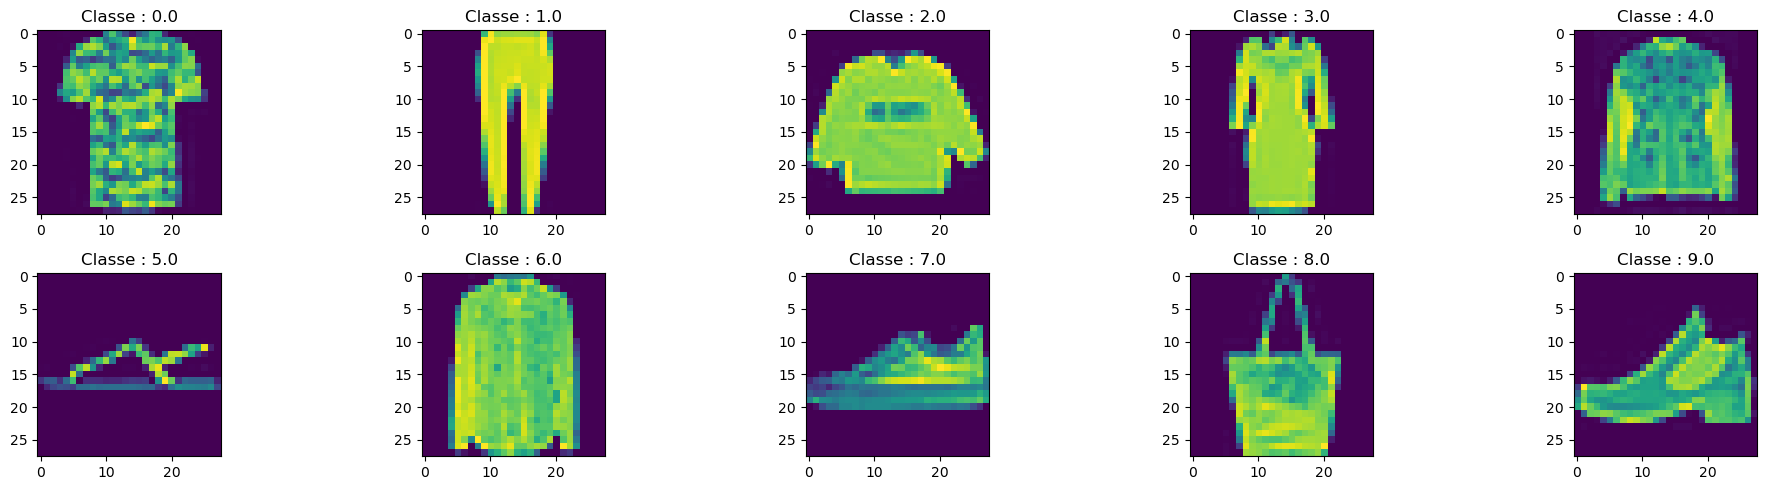

In [11]:
# Définir les cases
fig, axes = plt.subplots(2, len(labels_unique)//2, figsize=(20, 5))
axes = axes.flatten()

for i in range(len(labels_unique)):
    # Premier exemple pour chaque label
    exemple = data_train[data_train["label"] == labels_unique[i]].iloc[0]
    axes[i].imshow(np.array(exemple[1:]).reshape(28, 28))
    axes[i].set_title(f"Classe : {exemple['label']}")
plt.tight_layout()
plt.show()

---
# **Apprentissage Supervisé**


## Classification Binaire

On va tout d'abord tester nos algorithmes de classification binaires sur des sous ensembles du dataset afin de déterminer l'efficacité<br>
Algorithmes utilisés :
- Perceptron de Rosenblatt
- KNN

---
## __Perceptron de rosenblatt__

On va tester le perceptron sur des sous ensembles de 2 classes de la base Train<br>
Notre objectif sera de voir quelles sont les classes plus faciles a différencier deux-à-deux via un perceptron

### Classification entre t-shirt (classe 0) et pantalon (classe 1)

In [12]:
test_tshirt_pantalon = (data_train["label"] == 0) | (data_train["label"]  == 1) 
Xtrain = train_desc[test_tshirt_pantalon] # Dataset avec uniquement des pantalons et tshirt
Ytrain = train_label[test_tshirt_pantalon] # Possède uniquement les labels 0 (tshirt) et 1 (pantalon) 
Ytrain = 2*Ytrain -1 # On transforme les 0 en -1

test_tshirt_pantalon2 = (data_test["label"] == 0) | (data_test["label"]  == 1)
Xtest = test_desc[test_tshirt_pantalon2]
Ytest = test_label[test_tshirt_pantalon2]
Ytest = 2*Ytest - 1

In [22]:
perceptron = cl.ClassifierPerceptron(len(Xtrain[0]))
perceptron.train(Xtrain, Ytrain, nb_max=1000, verbose=True)
acc_train, acc_test= perceptron.accuracy(Xtrain, Ytrain), perceptron.accuracy(Xtest, Ytest)
acc_perceptron = acc_test
print("Accuracy sur le base train : ", acc_train)
print("Accuracy sur la base test : ", acc_test)

train Perceptron de rosenblatt : 1000 appels a train_step
Accuracy sur le base train :  1.0
Accuracy sur la base test :  0.9995


Résultat : Accuracy test sur le sous ensemble <b>Tshirt VS Pantalon : 99%</b><br>

### Classification entre t-shirt (classe 0) et manteau (classe 4)

In [15]:
Xtrain2 = train_desc[(data_train["label"] == 0) | (data_train["label"]  == 4)] # tshirt et manteau
Ytrain2 = train_label[(data_train["label"] == 0) | (data_train["label"]  == 4)]
Ytrain2 = 2*(Ytrain2 == 0) -1 #On transforme les 0 en -1

Xtest2 = test_desc[(data_test["label"] == 0) | (data_test["label"]  == 4)]
Ytest2 = test_label[(data_test["label"] == 0) | (data_test["label"]  == 4)]
Ytest2 = 2*(Ytest2 == 0) - 1

In [21]:
perceptron2 = cl.ClassifierPerceptron(len(Xtrain2[0]))
perceptron2.train(Xtrain2, Ytrain2, verbose=False)
acc_train, acc_test= perceptron2.accuracy(Xtrain2, Ytrain2), perceptron2.accuracy(Xtest2, Ytest2)
print("Accuracy sur le base train : ", acc_train)
print("Accuracy sur la base test : ", acc_test)

Accuracy sur le base train :  0.98675
Accuracy sur la base test :  0.9835


Résultat : Accuracy test sur le sous ensemble <b>Tshirt VS Pantalon : 99%</b><br>


### Classification entre chaque paire de classes possibles

In [19]:
perceptron_accuracies = []
accuracies_matrix = []
for _ in range(len(labels_unique)):
    accuracies_matrix.append([0]*len(labels_unique))

for i in range(len(labels_unique)):
    for j in range(i+1, len(labels_unique)):
        classe1 = labels_unique[i]
        classe2 = labels_unique[j]

        mtrain = (data_train["label"] == classe1) | (data_train["label"]  == classe2)
        Xtrain = train_desc[mtrain] 
        Ytrain = train_label[mtrain]
        Ytrain = 2*(Ytrain == classe1) -1

        mtest = (data_test["label"] == classe1) | (data_test["label"]  == classe2)
        Xtest = test_desc[mtest]
        Ytest = test_label[mtest]
        Ytest = 2*(Ytest == classe1) -1
        
        perceptron = cl.ClassifierPerceptron(len(Xtrain2[0]))
        perceptron.train(Xtrain, Ytrain, verbose=False)
        acc_test= perceptron.accuracy(Xtest, Ytest)
        perceptron_accuracies.append(acc_test)
        accuracies_matrix[i][j] = acc_test
        accuracies_matrix[j][i] = acc_test

In [20]:
float(np.mean(perceptron_accuracies))

0.970122222222222

Résultat : Accuracy test moyen sur l'<b>ensemble des paires possibles : 97.01%</b>

## Perceptron : comparaison des approches et de ses hyper-paramètres

### Accuracy et temps d'entraînement selon le nombres d'itérations

Graphiques réalisées à l'aide de l'IA générative Gemini

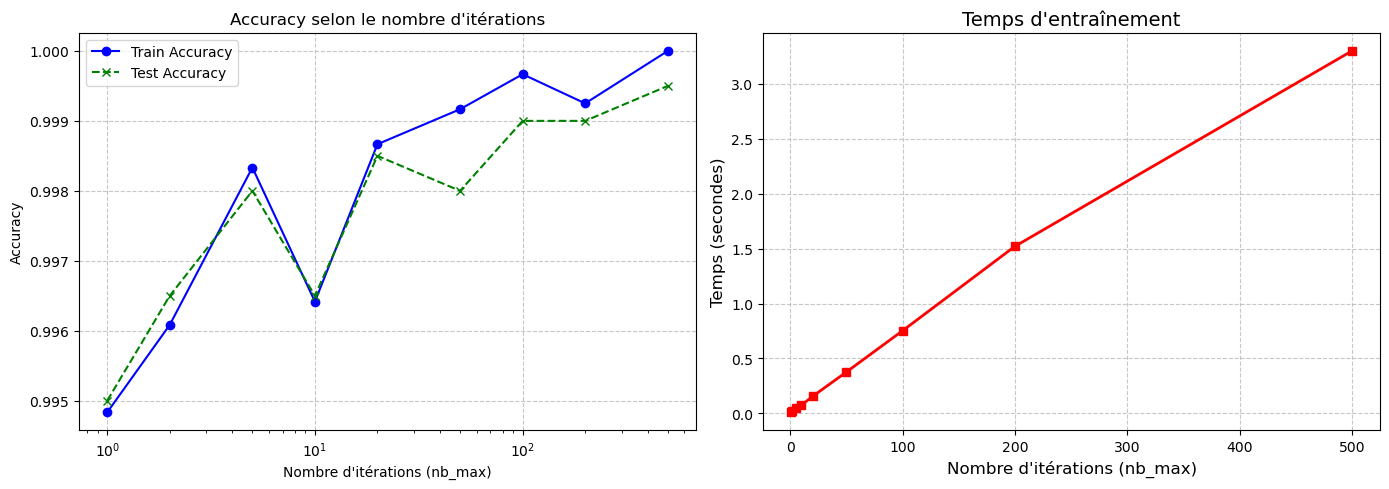

In [30]:
iterations = [1, 2, 5, 10, 20, 50, 100, 200, 500]
accuracy_train_perceptron_l = []
accuracy_test_perceptron_l = []
les_temps_perceptron = []
dim = len(Xtrain[0])

for i in iterations:
    perceptron = cl.ClassifierPerceptron(dim, learning_rate=0.01, init=True)
    tic = time.time()
    perceptron.train(Xtrain, Ytrain, nb_max=i, seuil=0.0, verbose=False) # seuil = 0.0 pour pas s'arrêter avant le nb d'itérations
    toc = time.time()
    les_temps_perceptron.append(toc - tic)
    
    accuracy_train = perceptron.accuracy(Xtrain, Ytrain)
    accuracy_train_perceptron_l.append(accuracy_train)
    accuracy_test = perceptron.accuracy(Xtest, Ytest)
    accuracy_test_perceptron_l.append(accuracy_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(iterations, accuracy_train_perceptron_l, marker='o', color='blue', label='Train Accuracy')
ax1.plot(iterations, accuracy_test_perceptron_l, marker='x', color='green', label='Test Accuracy', linestyle='--')
ax1.set_title("Accuracy selon le nombre d'itérations")
ax1.set_xlabel("Nombre d'itérations (nb_max)")
ax1.set_ylabel("Accuracy")
ax1.set_xscale('log') # log car on teste sur différentes ordres de grandeur
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(iterations, les_temps_perceptron, marker='s', color='red', linewidth=2)
ax2.set_title("Temps d'entraînement", fontsize=14)
ax2.set_xlabel("Nombre d'itérations (nb_max)", fontsize=12)
ax2.set_ylabel("Temps (secondes)", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Résultat : on en déduit que <b>plus le nombre d'itérations est élévé, plus la précision est élevé</b> et que la <b>complexité est linéaire</b>

### Accuracy et temps d'entraînement selon le learning rate

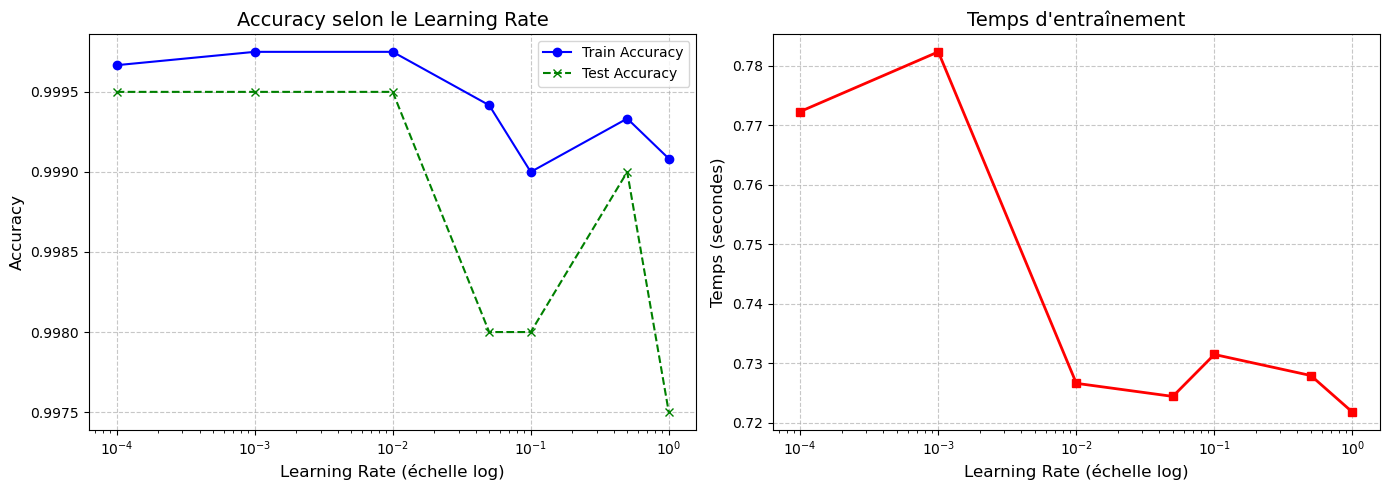

In [36]:
valeurs_learning_rate = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
accuracy_train_perceptron = []
accuracy_test_perceptron = []
les_temps_perceptron = []

for lr in valeurs_learning_rate:
    perceptron = cl.ClassifierPerceptron(dim, learning_rate=lr, init=True)
    tic = time.time()
    perceptron.train(Xtrain, Ytrain, verbose=False)
    toc = time.time()
    les_temps_perceptron.append(toc - tic)
    
    accuracy_train = perceptron.accuracy(Xtrain, Ytrain)
    accuracy_train_perceptron.append(accuracy_train)
    accuracy_test = perceptron.accuracy(Xtest, Ytest)
    accuracy_test_perceptron.append(accuracy_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(valeurs_learning_rate, accuracy_train_perceptron, marker='o', color='blue', label='Train Accuracy')
ax1.plot(valeurs_learning_rate, accuracy_test_perceptron, marker='x', color='green', label='Test Accuracy', linestyle='--')
ax1.set_title("Accuracy selon le Learning Rate", fontsize=14)
ax1.set_xlabel("Learning Rate (échelle log)", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.set_xscale('log')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(valeurs_learning_rate, les_temps_perceptron, marker='s', color='red', linewidth=2)
ax2.set_title("Temps d'entraînement", fontsize=14)
ax2.set_xlabel("Learning Rate (échelle log)", fontsize=12)
ax2.set_ylabel("Temps (secondes)", fontsize=12)
ax2.set_xscale('log')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Résultat : on en déduit qu'il y a un léger <b>sur-apprentissage</b> avec un learning rate élevée. De plus, <b>plus le learning est élevée, plus le temps d'entraînement est faible</b>

## Matrice représentant l'accuracy entre les classes i et j :

Aide de Gemini et de la documentation seaborn pour afficher la matrice des accuracies

Text(0.5, 1.0, 'Accuracy du perceptron classe i VS classe j')

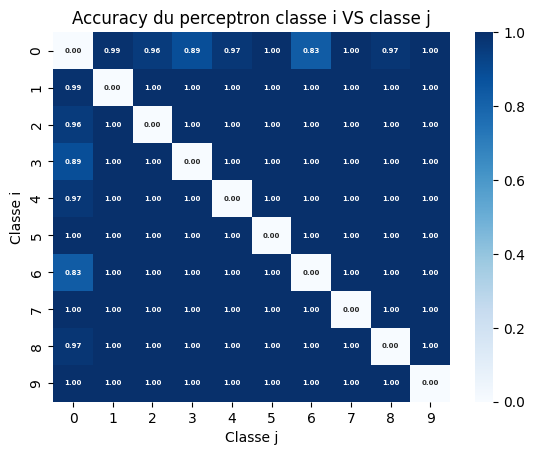

In [75]:
sns.heatmap(accuracies_matrix, 
            annot=True,          # Affiche les valeurs dans les cases
            fmt=".2f",           # Format à 2 décimales
            cmap="Blues",       # Palette de couleurs (Jaune -> Vert -> Bleu)
            vmin=0, vmax=1,      # Borner l'échelle de l'accuracy entre 0 et 1
            xticklabels=labels_unique, 
            yticklabels=labels_unique,
            annot_kws={"size": 5, "weight": "bold"})

plt.xlabel("Classe j")
plt.ylabel("Classe i")
plt.title("Accuracy du perceptron classe i VS classe j")

Résultat : on remarque que les erreurs se concentrent sur les vêtements qui se rapprochent visuellement à l'oeil-nu, par exemple la classe 0 (t-shirt) et 6 (chemise)

---
## __K-plus proches voisins__ : classification binaire

In [37]:
Knn1 = cl.ClassifierKNN(len(Xtrain[0]), k=10)
Knn1.train(Xtrain, Ytrain)

K initialise : 10


In [38]:
Knn1.accuracy(Xtest[:100], Ytest[:100])

0.99

In [39]:
predictions = np.array([Knn1.predict(x) for x in Xtest[:200]])

<Axes: >

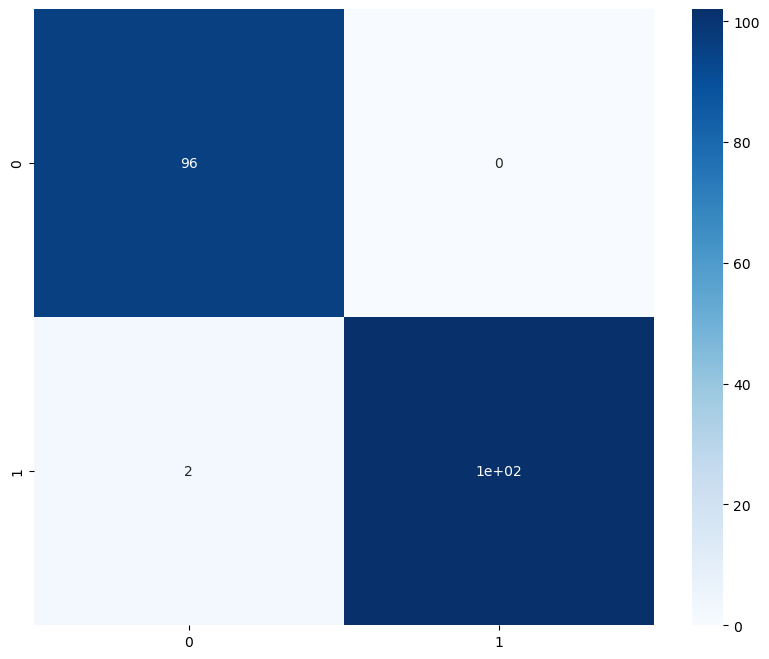

In [40]:
mc = ev.matrice_confusion(predictions, Ytest[:200])
plt.figure(figsize=(10, 8))
sns.heatmap(mc, annot=True, cmap='Blues',
            xticklabels=list(range(2)), 
            yticklabels=list(range(2)))


## Comparaison des accuracys pour les k de 1 à 9 

### Classification entre t-shirt (classe 0) et pantalon (classe 1)

In [41]:
acc_knn = []

for k_value in range(1, 10):
    knn = cl.ClassifierKNN(len(Xtrain[0]), k=k_value)
    knn.train(Xtrain, Ytrain)
    acc_knn.append(knn.accuracy(Xtest[:200], Ytest[:200]))

acc_knn

K initialise : 1
K initialise : 2
K initialise : 3
K initialise : 4
K initialise : 5
K initialise : 6
K initialise : 7
K initialise : 8
K initialise : 9


[0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99]

### Classification entre t-shirt (classe 0) et manteau (classe 4)

In [42]:
acc_knn2 = []

for k_value in range(1, 10):
    knn = cl.ClassifierKNN(len(Xtrain2[0]), k=k_value)
    knn.train(Xtrain2, Ytrain2)
    acc_knn2.append(knn.accuracy(Xtest2[:200], Ytest2[:200]))

acc_knn2

K initialise : 1
K initialise : 2
K initialise : 3
K initialise : 4
K initialise : 5
K initialise : 6
K initialise : 7
K initialise : 8
K initialise : 9


[0.965, 0.975, 0.96, 0.97, 0.96, 0.97, 0.965, 0.97, 0.97]

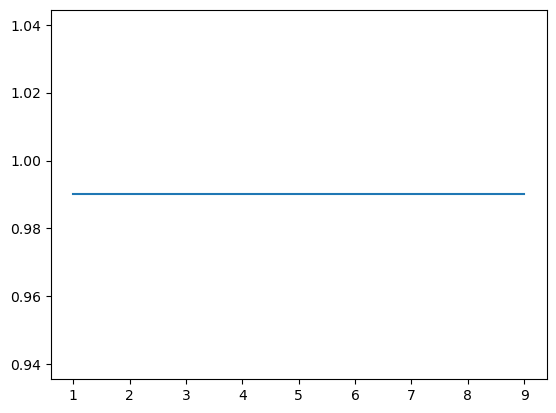

In [43]:
plt.plot(range(1, 10), acc_knn)

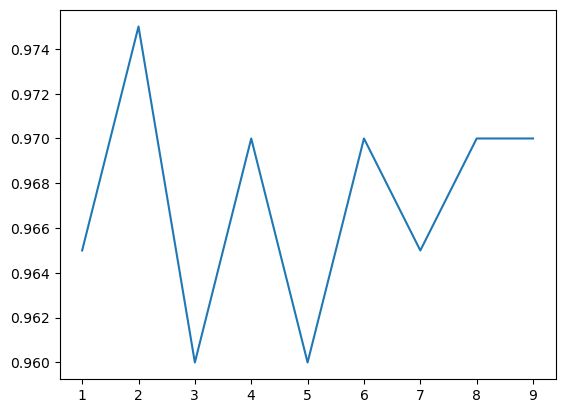

In [44]:
plt.plot(range(1, 10), acc_knn2)

Remarque : Le coût d'une seule prédiction avec Knn est en O(nd) avec d la dimension d'un exemple (ici 60000*784 = 47040000 opérations)

## **Arbres de décision**

### Arbres de décision binaires

 Classification entre t-shirt (classe 0) et pantalon (classe 1)

In [46]:
arbre = cl.ClassifierArbreNumerique(len(Xtrain[0]), 0.1, LNoms=data_train.columns[1:])
arbre.train(Xtrain[:1000], Ytrain[:1000])
acc_arbre = arbre.accuracy(Xtest, Ytest)
acc_arbre

0.986

### Testons le temps de calcul en augmentant la taille de l'ensemble

In [47]:
#Temps de calcul evaluation
arbre = cl.ClassifierArbreNumerique(len(Xtrain[0]), 0.1, LNoms=data_train.columns[1:])

les_temps = []
for taille in range(100, 1100, 200):
    tic = time.time()
    arbre = cl.ClassifierArbreNumerique(len(Xtrain[0]), 0.1, LNoms=data_train.columns[1:])
    arbre.train(Xtrain[:taille], Ytrain[:taille])
    toc = time.time()
    print(toc-tic)
    les_temps.append(toc-tic)

4.348649978637695
6.674462080001831
6.796599864959717
8.281113147735596
14.3167405128479


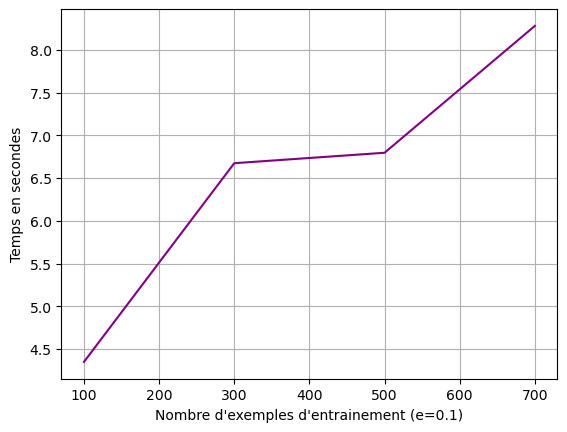

In [49]:
plt.plot(range(100, 900, 200), les_temps[:-1], color="purple")
plt.ylabel("Temps en secondes")
plt.xlabel("Nombre d'exemples d'entrainement (e=0.1)")
plt.grid()

Résultat : Un temps d'apprentissage qui <b>augmente linéairement avec le nombre d'exemples</b>

# Random Forest 

In [14]:
rf = cl.RandomForest(len(train_desc[0]), epsilon=0.3, nb_arbres=50, pourc=0.02)
rf.train(train_desc, train_label, LNoms=data_train.columns[1:], verbose=True)
rf.accuracy(test_desc, test_label)

Arbre 0 entrainé avec 1200 exemples
Arbre 1 entrainé avec 1200 exemples
Arbre 2 entrainé avec 1200 exemples
Arbre 3 entrainé avec 1200 exemples
Arbre 4 entrainé avec 1200 exemples
Arbre 5 entrainé avec 1200 exemples
Arbre 6 entrainé avec 1200 exemples
Arbre 7 entrainé avec 1200 exemples
Arbre 8 entrainé avec 1200 exemples
Arbre 9 entrainé avec 1200 exemples
Arbre 10 entrainé avec 1200 exemples
Arbre 11 entrainé avec 1200 exemples
Arbre 12 entrainé avec 1200 exemples
Arbre 13 entrainé avec 1200 exemples
Arbre 14 entrainé avec 1200 exemples
Arbre 15 entrainé avec 1200 exemples
Arbre 16 entrainé avec 1200 exemples
Arbre 17 entrainé avec 1200 exemples
Arbre 18 entrainé avec 1200 exemples
Arbre 19 entrainé avec 1200 exemples
Arbre 20 entrainé avec 1200 exemples
Arbre 21 entrainé avec 1200 exemples
Arbre 22 entrainé avec 1200 exemples
Arbre 23 entrainé avec 1200 exemples
Arbre 24 entrainé avec 1200 exemples
Arbre 25 entrainé avec 1200 exemples
Arbre 26 entrainé avec 1200 exemples
Arbre 27 en

0.8273

## Accuracy Random Forest de 50 arbres (2% du dataset par arbre) : **82.73%**

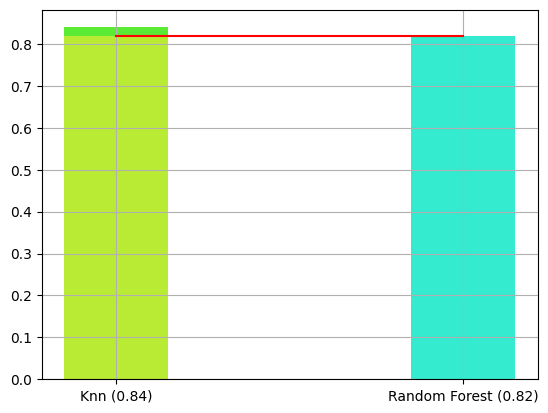

In [43]:
plt.bar(["Knn (0.84)", "Random Forest (0.82)"], np.array([0.84, 0.82]), width=0.3, color=["#5beb34", "#34ebcf"])
plt.bar(["Knn (0.84)", "Random Forest (0.82)"], np.array([0.82, 0.82]), width=0.3, color=["#baeb34", "#34ebcf"])
plt.grid()
plt.plot(np.ones(2)*0.82, color="red")

In [51]:
X_train = np.array(data_train.iloc[:, 1:])
Y_train = np.array(data_train["label"])

X_test = np.array(data_test.iloc[:, 1:])
Y_test = np.array(data_test["label"])

## Arbre de décision multi-classe

In [55]:
accs = []
for e in range(1, 7):
    eps = e/10
    arbre_multiclasse = cl.ClassifierArbreNumerique(len(Xtrain[0]), eps, LNoms=data_train.columns[1:])
    arbre_multiclasse.train(X_train[:100], Y_train[:100])
    a = arbre_multiclasse.accuracy(X_test, Y_test)
    accs.append(a)
    print(a)

0.5514
0.5514
0.5514
0.5514
0.5514
0.5471


---

## Point sur les accuracies (classification binaire)


<BarContainer object of 4 artists>

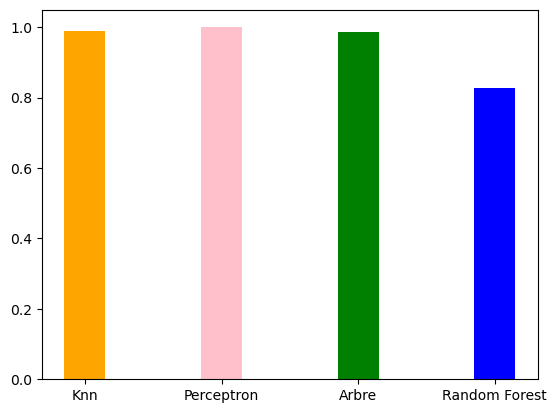

In [61]:
plt.bar(["Knn", "Perceptron", "Arbre", "Random Forest"], np.array([np.mean(acc_knn), acc_perceptron, acc_arbre, 0.827]), width=0.3, color=["orange", "pink", "green", "blue"])

<BarContainer object of 3 artists>

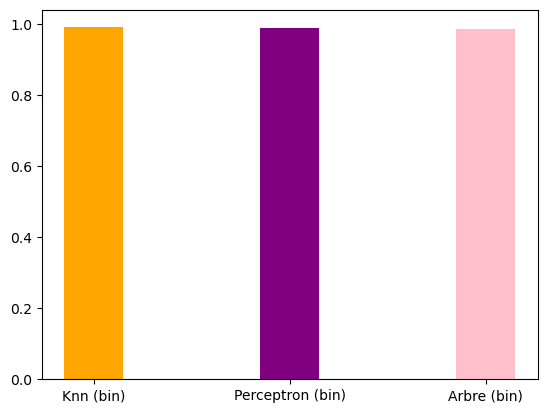

In [62]:
plt.bar(["Knn (bin)", "Perceptron (bin)", "Arbre (bin)"], np.array([0.99, 0.989, 0.986]), width=0.3, color=["orange", "purple", "pink", "blue", "red"])

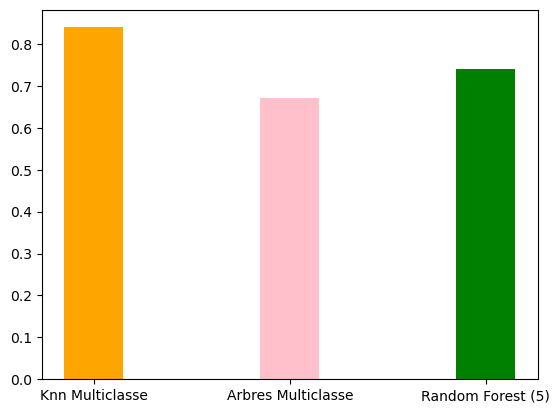

In [63]:
plt.bar(["Knn Multiclasse", "Arbres Multiclasse" ,"Random Forest (5)"], np.array([0.84, 0.6719, 0.74]), width=0.3, color=["orange", "pink", "green"])

plt.show()

## **Classification Multi-classe**

In [64]:
k_multiclasses_acc = []

for k_value in range(1, 10):
    classifieurKNN_multiclasse = cl.ClassifierKNN2(len(train_desc[0]), k=k_value)
    classifieurKNN_multiclasse.train(train_desc, train_label)
    k_multiclasses_acc.append(classifieurKNN_multiclasse.accuracy(test_desc[:100], test_label[:100]))

K initialise : 1
K initialise : 2
K initialise : 3
K initialise : 4
K initialise : 5
K initialise : 6
K initialise : 7
K initialise : 8
K initialise : 9


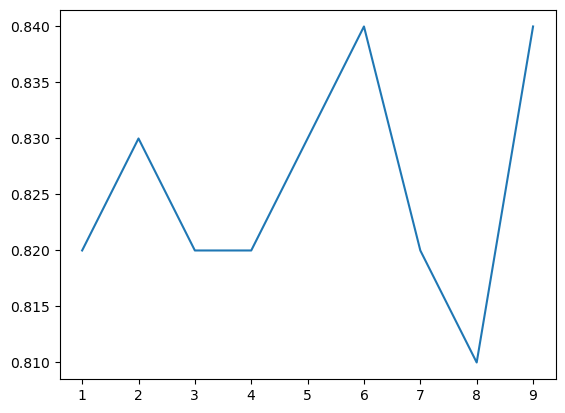

In [65]:
plt.plot(range(1,10), k_multiclasses_acc)

Résultat : meilleure accuracy avec k=10, <b>84%</b>

Evaluation Knn multi-classe par matrice de confusion

K initialise : 10


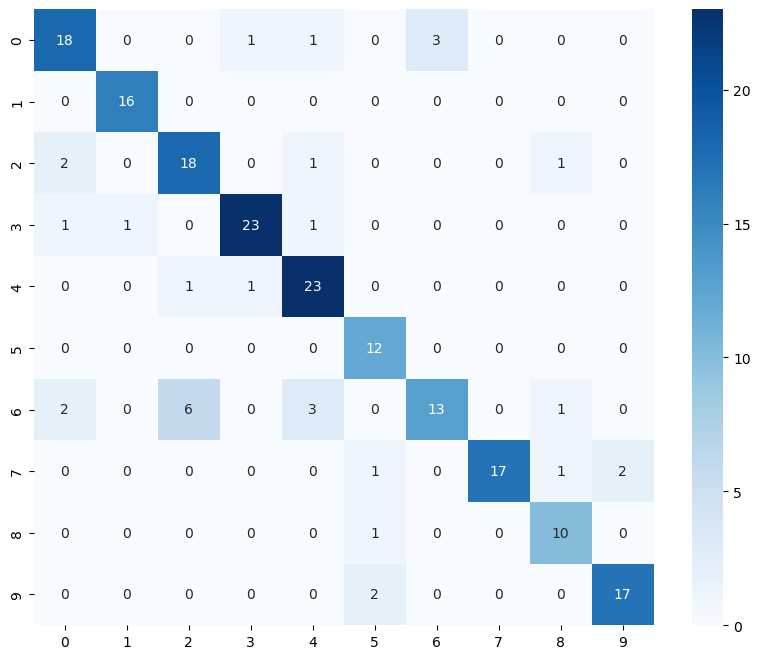

In [66]:
classifieurKNN_multiclasse = cl.ClassifierKNN2(len(train_desc[0]), k=10)
classifieurKNN_multiclasse.train(train_desc, train_label)
pred = [classifieurKNN_multiclasse.predict(x) for x in test_desc[:200]]
lab = test_label[:200]
ev.affichage_matrice_confusion(ev.matrice_confusion(pred, lab))

---

# **Classification non supervisée**

## **Classification Ascendante Hiérarchique**

Nous allons effectuer une classification ascendate hiérarchique<br>
On va se limiter à un sous ensemble afin d'éviter un calcul trop long

In [47]:
tirage_CAH = np.random.permutation(len(data_train))[:100]
data_CAH = data_train.iloc[tirage_CAH]

### Choisir un Linkage :

In [48]:
linkages = [clust.LinkageCentroide(), clust.LinkageAverage(), clust.LinkageSimple(), clust.LinkageComplete()]

In [49]:
resultats = []
for linkage in linkages:
    resultats.append(clust.CHA_algorithme(data_CAH, linkage))

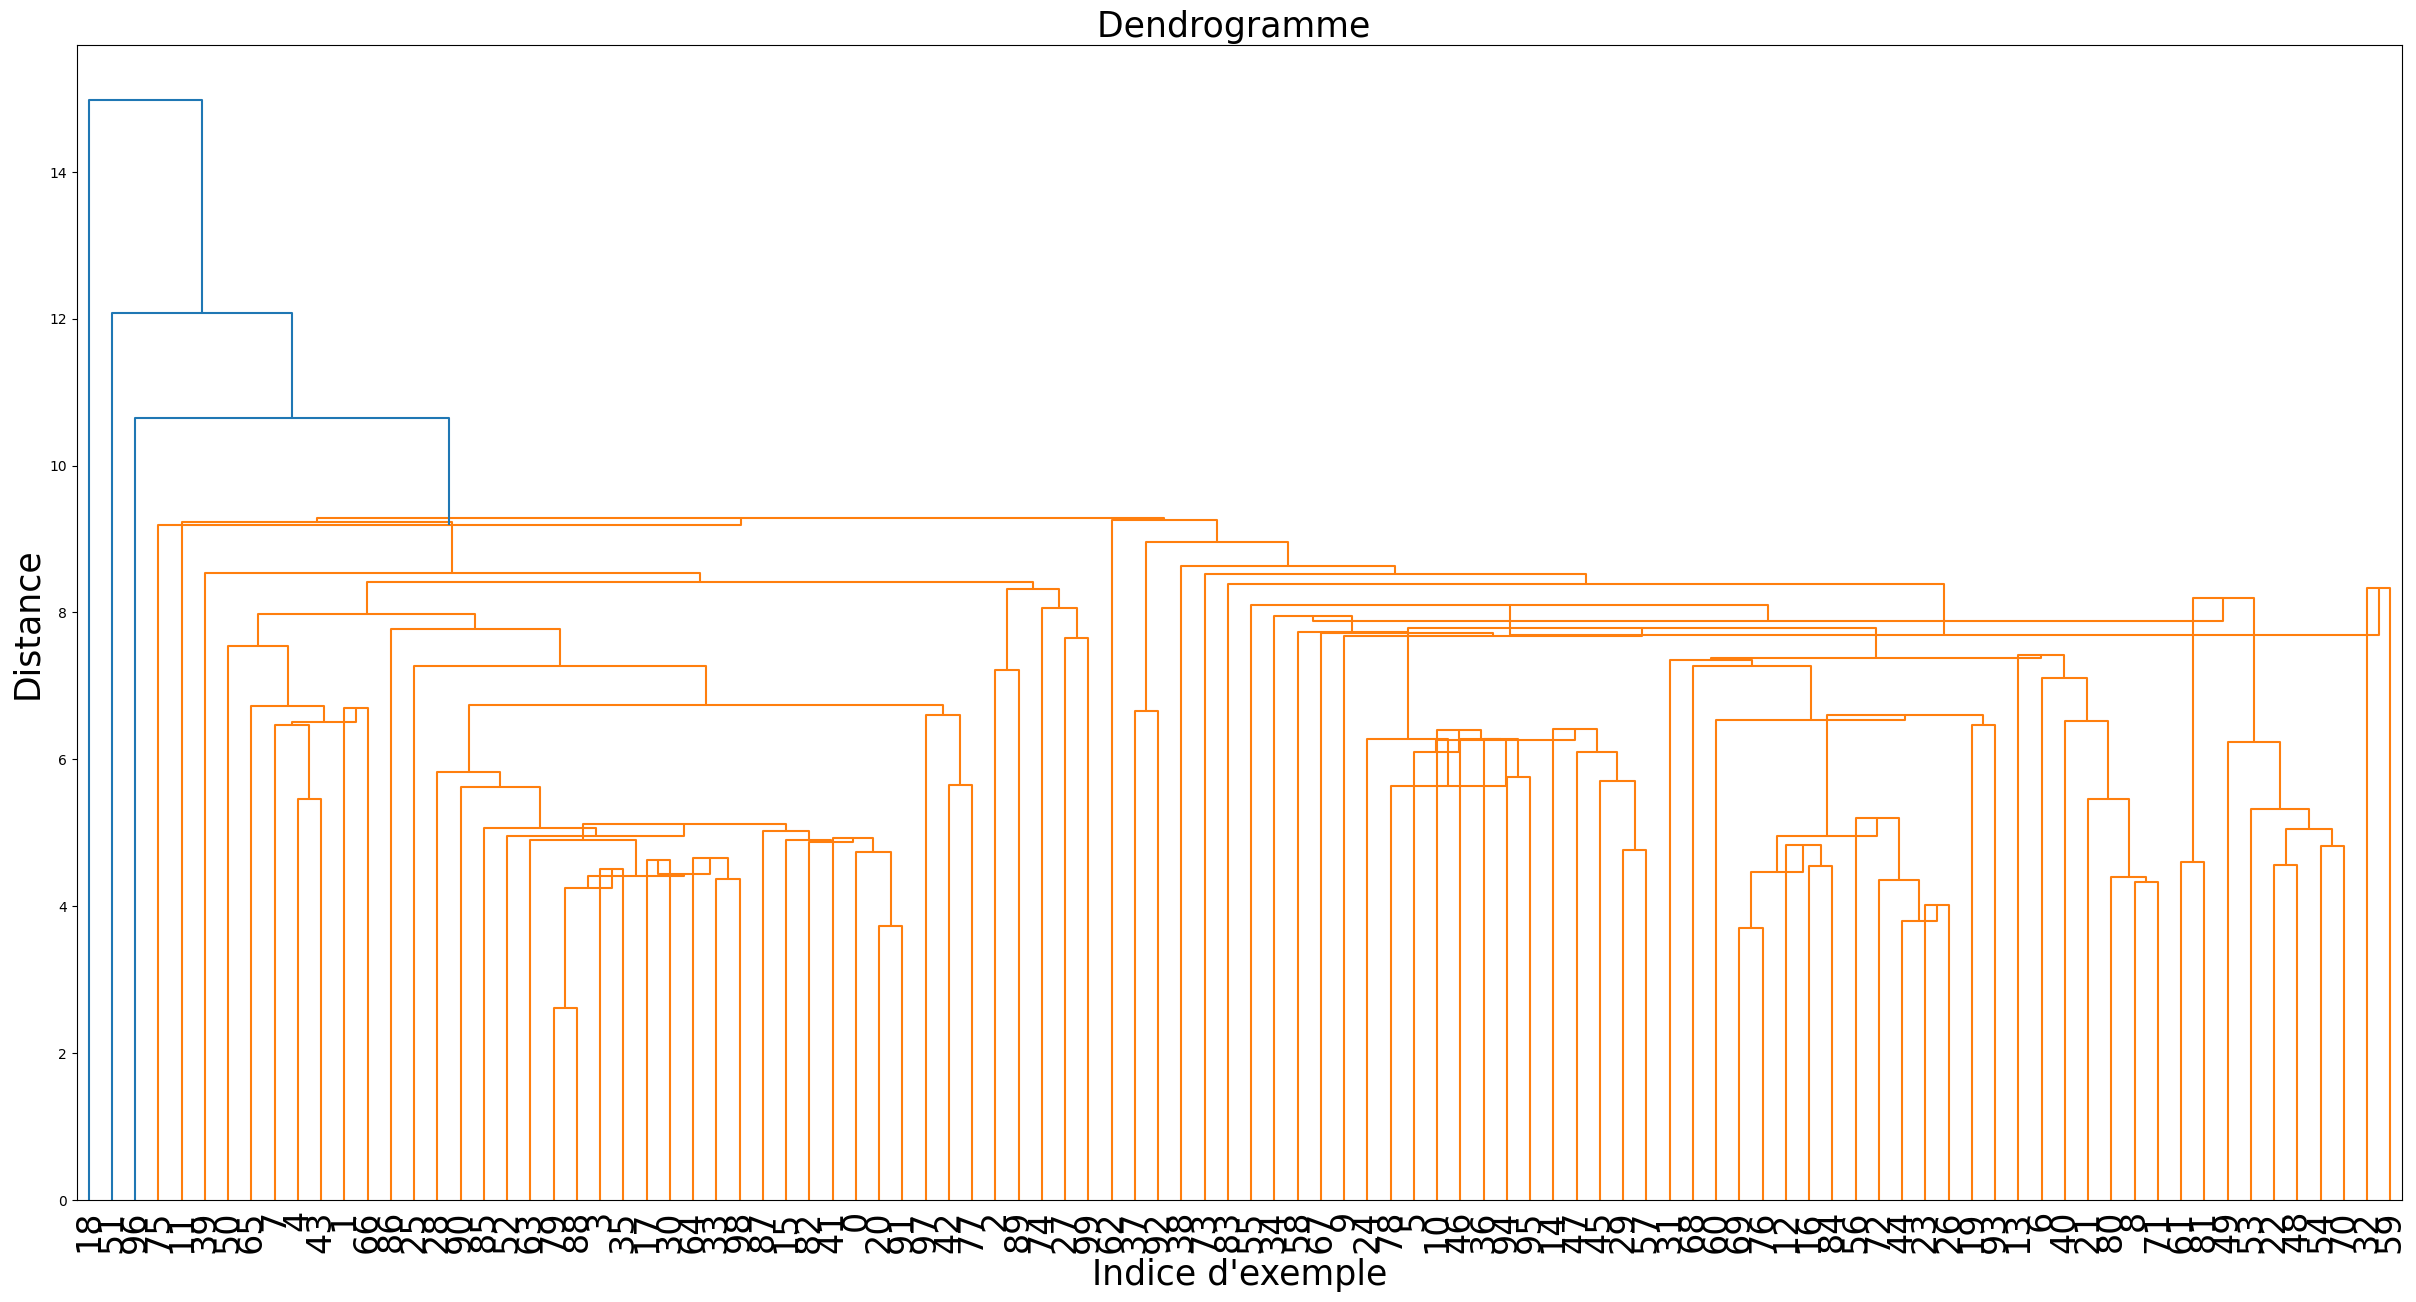

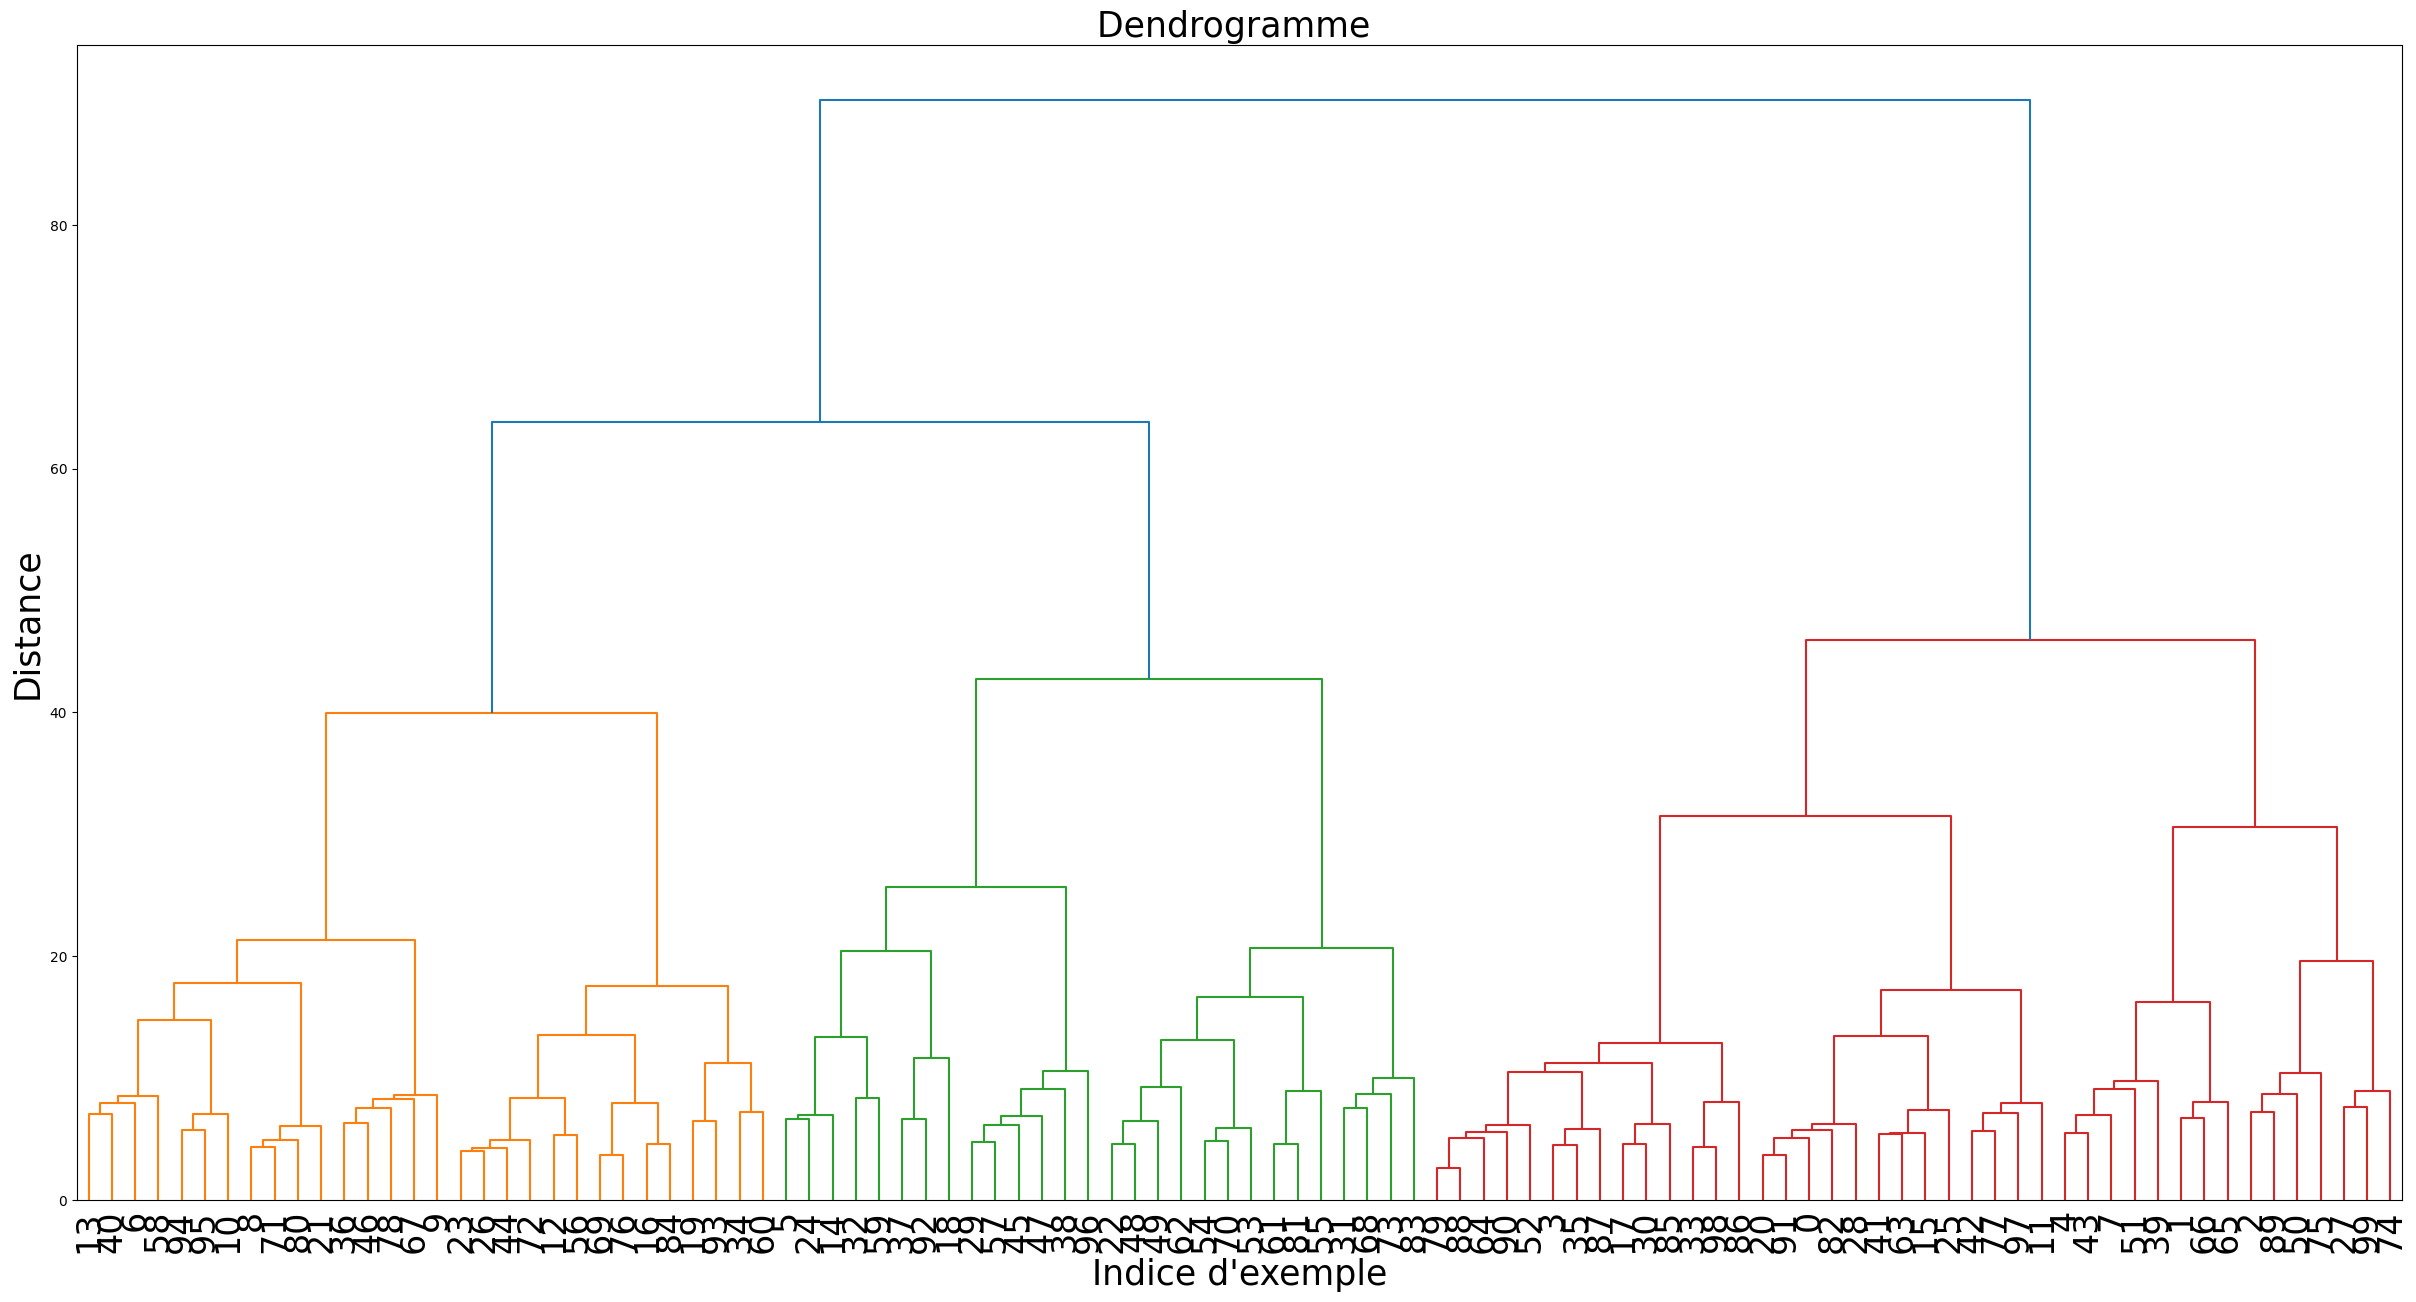

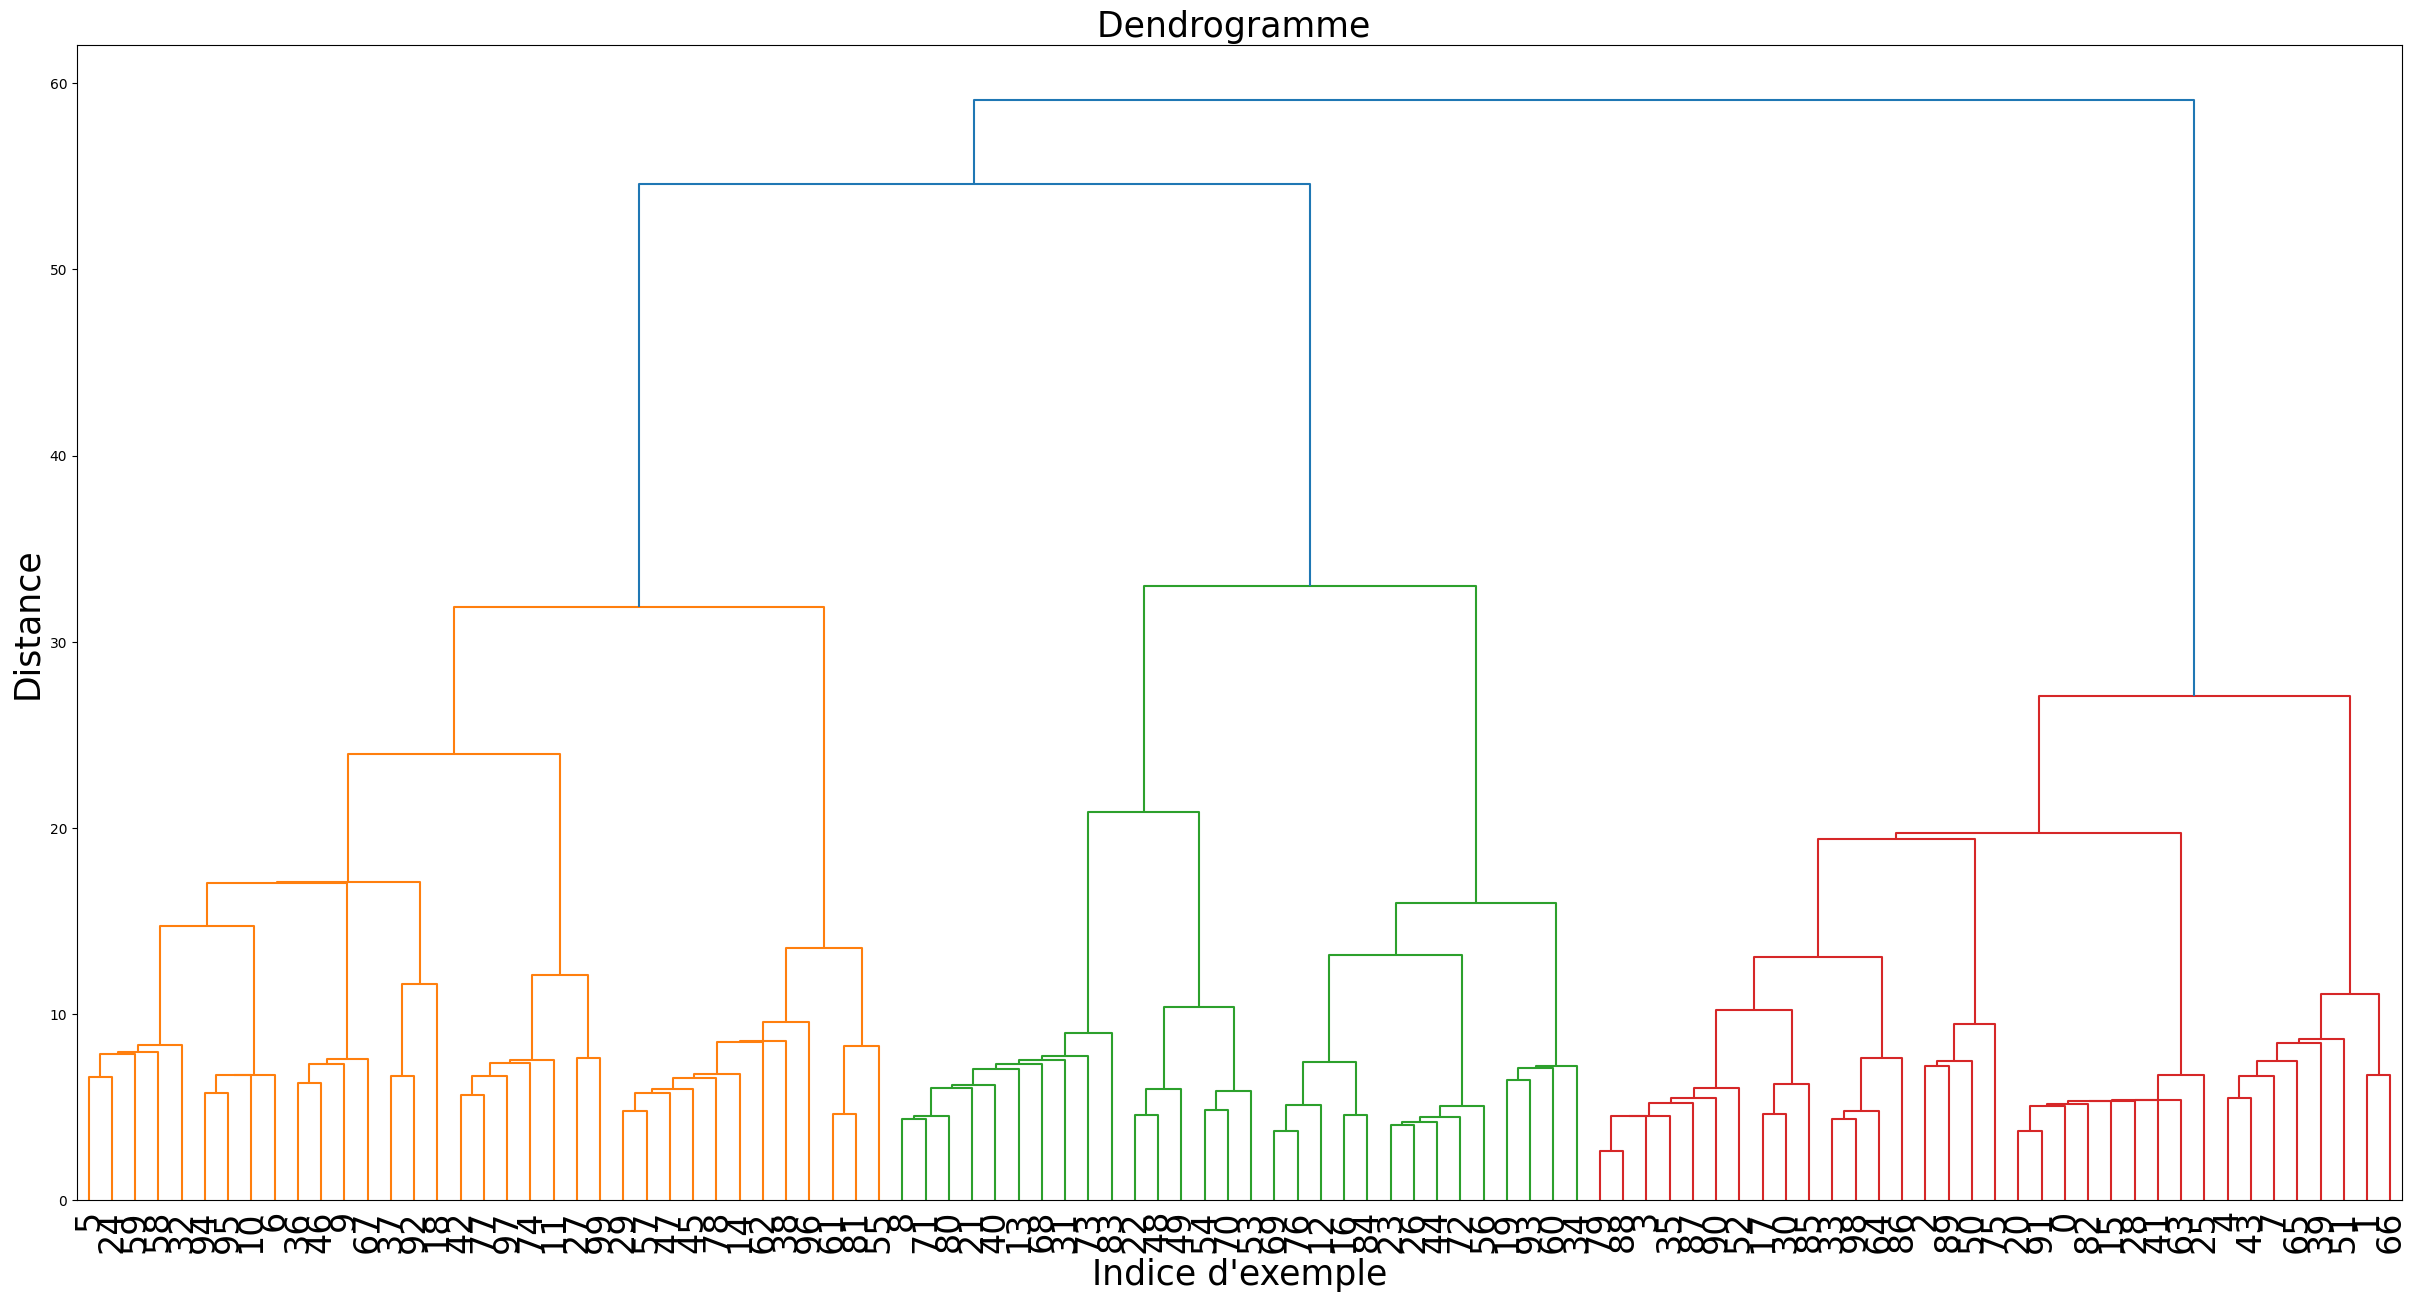

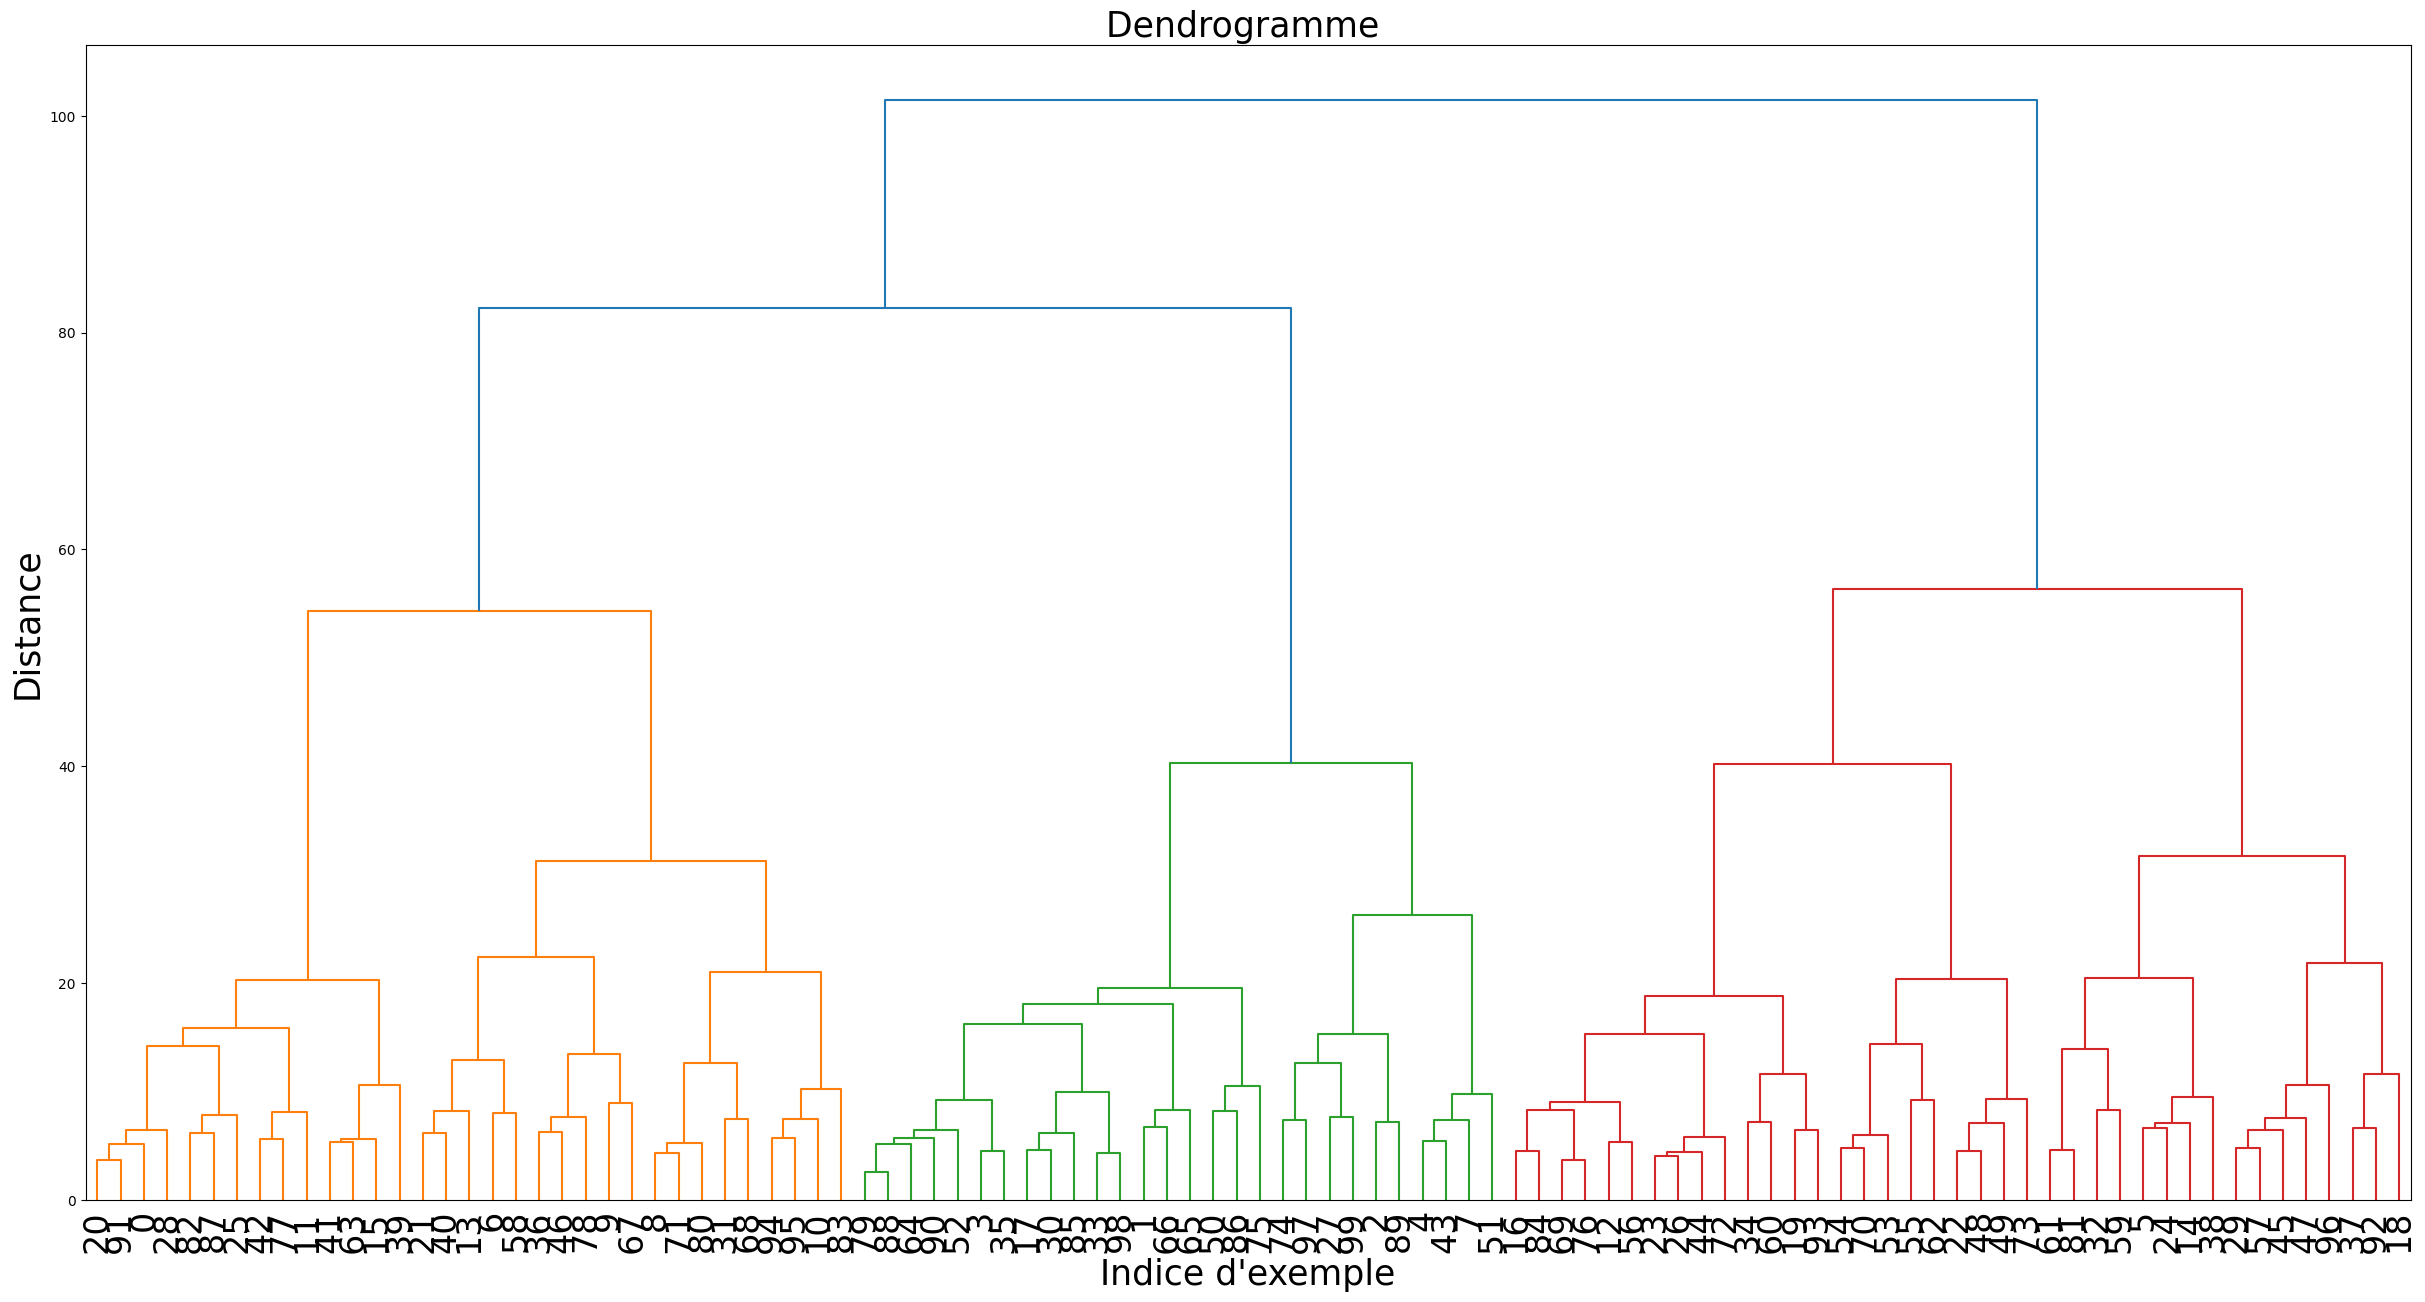

In [50]:

for r in resultats:
    clust.CHA_dendrogramme(r)

---
## __Classification non supervisée : KMoyennes__

In [70]:
KMeans = cl.KMoyennes(10)
np.random.seed(42)
tirage = np.random.permutation(2000)

In [71]:
Base = data_train.iloc[:, 1:].iloc[tirage]
Labels = data_train.iloc[tirage]["label"]

In [72]:
centres , matrice = KMeans.train(Base, 0.01, 1000, verbose=True)

Itération n°0 : inertie = 72889.10306944174 Différence = --
Itération n°0 : inertie = 67814.18431394978 Différence = 5074.918755491963
Itération n°1 : inertie = 65998.71758074705 Différence = 1815.4667332027311
Itération n°2 : inertie = 65145.45915538737 Différence = 853.2584253596797
Itération n°3 : inertie = 64728.5461053207 Différence = 416.91305006667244
Itération n°4 : inertie = 64432.27838939468 Différence = 296.2677159260129
Itération n°5 : inertie = 64002.25597439668 Différence = 430.02241499800584
Itération n°6 : inertie = 63619.957094051075 Différence = 382.2988803456028
Itération n°7 : inertie = 63450.76037360071 Différence = 169.19672045036714
Itération n°8 : inertie = 63373.78557879734 Différence = 76.97479480336915
Itération n°9 : inertie = 63338.27450555951 Différence = 35.511073237830715
Itération n°10 : inertie = 63291.119044260886 Différence = 47.15546129862196
Itération n°11 : inertie = 63254.4636416729 Différence = 36.65540258798865
Itération n°12 : inertie = 63223.

In [73]:
labels, counts = np.unique(Labels.iloc[matrice[0]], return_counts=True) #On recupere les classes des points groupés autour de C0


## **Indice de dunn (utilise la librairie scipy)**

In [74]:
from scipy.spatial.distance import pdist, cdist
def dunn(clusters:np.array):
    
    max_comp = 0.0
    
    for cluster in clusters:
        if len(cluster) > 1:
            comp = pdist(cluster).max()
            if comp > max_comp:
                max_comp = comp

    if max_comp == 0:
        return np.inf

    min_distance_inter = np.inf
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            d_min = cdist(clusters[i], clusters[j]).min()
            if d_min < min_distance_inter:
                min_distance_inter = d_min
    return min_distance_inter / max_comp

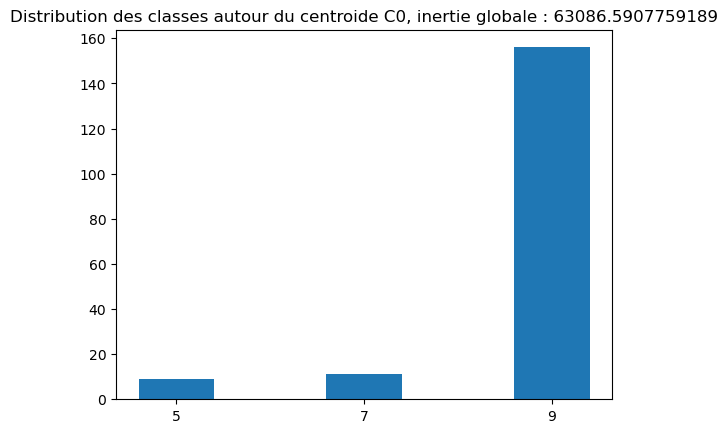

In [75]:
plt.bar(labels, counts)
plt.xticks(labels)
plt.title(f"Distribution des classes autour du centroide C0, inertie globale : {KMeans.inertie_globale(Base, matrice)}")
plt.show()

## Kmoyennes : affichage des centroïdes calculés par l'algorithme

Affichage des Centroïdes calculés par le KMoyennes


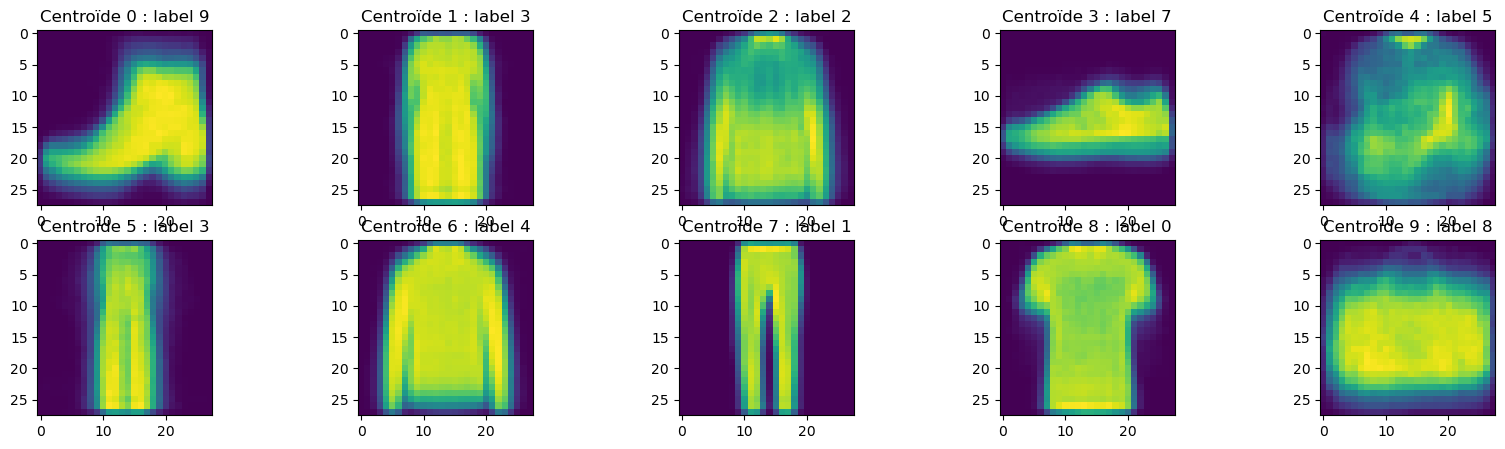

In [76]:
fig, axes = plt.subplots(2, len(centres)//2, figsize=(20, 5))
axes = axes.flatten()

print("Affichage des Centroïdes calculés par le KMoyennes")
for i in range(len(centres)):
    axes[i].imshow(np.array(centres[i]).reshape(28, 28))
    labels, counts = np.unique(Labels.iloc[matrice[i]], return_counts=True)
    axes[i].set_title(f"Centroïde {i} : label {labels[np.argmax(counts)]}") #On associe au cluster le label majoritaire des exemples du cluster

## Ce qu'on remarque

On voit que le clustering a donné des resultats cohérents (comme la classe pantalon par exemple) mais aussi quelques bizarreries :
- On a un cluster 4 avec un centroïde qui ne ressemble (presque) a rien car les images sont trop différentes, mais on peut quand meme distinguer légerement la forme du label (à comparer avec le point moyen du label 5)
- On remarque 2 fois la classe "pantalon" cela peut être du à l'aléatoire de l'initialisation du clustering 

On peut analyser les exemples du cluster 4 pour voir

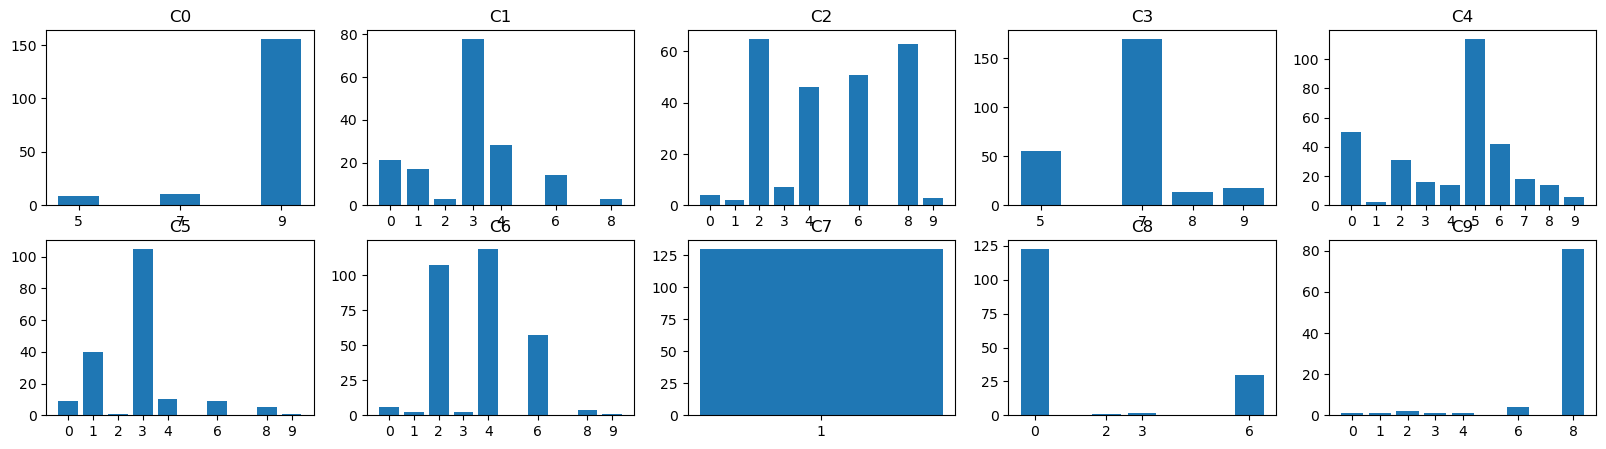

In [77]:

fig, axes = plt.subplots(2, len(centres)//2, figsize=(20, 5))
axes = axes.flatten()
for i in range(len(centres)):
    labels, counts = np.unique(Labels.iloc[matrice[i]], return_counts=True) 
    axes[i].bar(labels, counts)
    axes[i].set_xticks(labels)
    axes[i].set_title(f"C{i}")

Les barres représentent la répartition de chaque classe dans chacun des clusters

Le cluster C4 est le seul composé de toutes les classes (avec en plus une distribution assez égale si on enleve la classe 5) ce qui explique pourquoi il ne ressemble pas a grand chose malgré le fait qu'on puisse quand même distinguer légerement la forme de la classe 5.

## **Analyse du KMeans (complexité + inertie globale)**

In [32]:
inerties = []
liste_dunn = []
for k in range(1, 11):
    clasK = cl.KMoyennes(k)
    tirage = np.random.permutation(len(data_train))[:2000]
    B = data_train.iloc[:, 1:].iloc[tirage]
    Labels = data_train.iloc[tirage]["label"]
    c , m = clasK.train(B, 0.01, 1000)
    clusters = [np.array(data_train.iloc[m[c]]) for c in range(len(c))]
    di = dunn(clusters)
    print(f"Avancement : {k*10}%")
    liste_dunn.append(di)
    inerties.append(clasK.inertie_globale(B, m))

Avancement : 10%
Avancement : 20%
Avancement : 30%
Avancement : 40%
Avancement : 50%
Avancement : 60%
Avancement : 70%
Avancement : 80%
Avancement : 90%
Avancement : 100%


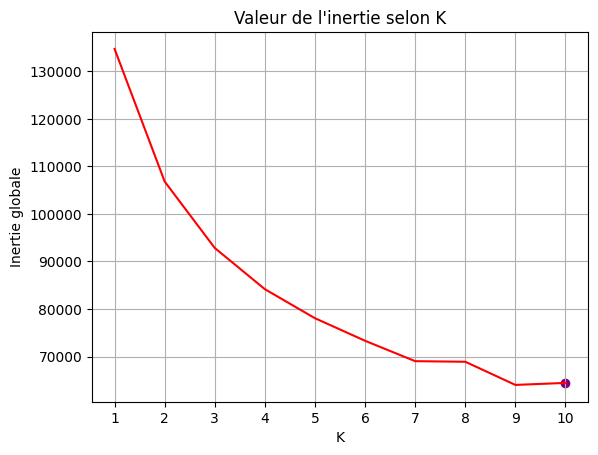

In [33]:
plt.plot(range(1, 11), inerties, color='red')
plt.xticks(range(1, 11))
plt.scatter([10], [inerties[9]], color='purple')
plt.grid()
plt.title("Valeur de l'inertie selon K")
plt.xlabel("K")
plt.ylabel("Inertie globale")
plt.show()

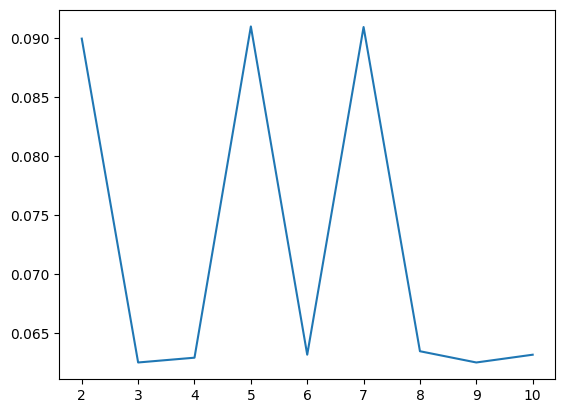

In [35]:
plt.plot(range(1, 11), liste_dunn)